In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/cifar-10/trainLabels.csv
/kaggle/input/competitions/cifar-10/sampleSubmission.csv
/kaggle/input/competitions/cifar-10/test.7z
/kaggle/input/competitions/cifar-10/train.7z


# Notebook 3 — Robust Training

**Goal:** Train a ResNet-18 model on CIFAR-10 using Adversarial Training (PGD-training). This hardens the model against gradient-based attacks.

**Data:** We reuse the exact same stratified splits to maintain total isolation of the test dataset.
**Method:** Generate PGD adversarial examples on the fly during the train loop, and calculate loss entirely on the perturbed images.

**Outputs:**
- `outputs/checkpoints/robust_resnet18.pth` — best robust epoch weights
- `outputs/training_curves/robust_train.csv` — per-epoch metrics

---
## Cell 1 — Imports & Config

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import subprocess
import os
import time
import glob

# ── Reproducibility ──
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Hyperparameters ──
BATCH_SIZE = 128
EPOCHS = 30
LEARNING_RATE = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

# ── PGD Training Parameters ──
PGD_EPSILON = 8/255.0
PGD_ALPHA = 2/255.0
PGD_STEPS = 7   # 7 steps is standard for robust training efficiency
PGD_TRAIN_STEPS = 5
PGD_EVAL_STEPS = 10

# ── Device ──
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Kaggle input paths ──
KAGGLE_INPUT = '/kaggle/input/competitions/cifar-10'
TRAIN_ARCHIVE = f'{KAGGLE_INPUT}/train.7z'
LABELS_CSV    = f'{KAGGLE_INPUT}/trainLabels.csv'

# ── Extraction directory ──
EXTRACT_DIR = '/kaggle/working/cifar10_extracted'
TRAIN_IMG_DIR = f'{EXTRACT_DIR}/train'

# ── Output paths ──
IS_KAGGLE = os.path.exists('/kaggle/working')
OUTPUT_DIR = '/kaggle/working/outputs' if IS_KAGGLE else '../outputs'
# CHECKPOINT_DIR = f'{OUTPUT_DIR}/checkpoints'
CURVES_DIR = f'{OUTPUT_DIR}/training_curves'

# os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(CURVES_DIR, exist_ok=True)

CHECKPOINT_PATH = f'{OUTPUT_DIR}/robust_resnet18.pth'
CURVES_PATH = f'{CURVES_DIR}/robust_train.csv'

print(f"Training on: {DEVICE}")
print(f"Kaggle environment: {IS_KAGGLE}")
print(f"Saving robust checkpoint to: {CHECKPOINT_PATH}")

Training on: cuda
Kaggle environment: True
Saving robust checkpoint to: /kaggle/working/outputs/robust_resnet18.pth


---
## Cell 2 — Extract Dataset

In [3]:
# ── Extract train.7z if not already extracted ──
os.makedirs(EXTRACT_DIR, exist_ok=True)

if os.path.exists(TRAIN_IMG_DIR) and len(os.listdir(TRAIN_IMG_DIR)) > 0:
    print(f"Train images already extracted at {TRAIN_IMG_DIR}")
else:
    print(f"Extracting {TRAIN_ARCHIVE} ...")
    result = subprocess.run(
        ['7z', 'x', TRAIN_ARCHIVE, f'-o{EXTRACT_DIR}', '-y'],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f"Error extracting: {result.stderr}")
        raise RuntimeError("Failed to extract train.7z")
    print("Extraction complete.")

# Verify extraction
num_images = len(glob.glob(f'{TRAIN_IMG_DIR}/*.png'))
print(f"Total images found: {num_images:,}")

# Load labels CSV
labels_df = pd.read_csv(LABELS_CSV)
print(f"Labels CSV shape: {labels_df.shape}")
print(f"\nLabel distribution:\n{labels_df['label'].value_counts().sort_index()}")
print(f"\nSample rows:")
labels_df.head()

Extracting /kaggle/input/competitions/cifar-10/train.7z ...
Extraction complete.
Total images found: 50,000
Labels CSV shape: (50000, 2)

Label distribution:
label
airplane      5000
automobile    5000
bird          5000
cat           5000
deer          5000
dog           5000
frog          5000
horse         5000
ship          5000
truck         5000
Name: count, dtype: int64

Sample rows:


,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


---
## Cell 3 — Dataset Splitting & DataLoaders
Identical split mechanics (50K/5K/5K) applied.

In [4]:
# ── CIFAR-10 constants ──
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CIFAR10_CLASSES)}

class CIFAR10Dataset(Dataset):
    def __init__(self, image_ids, labels, img_dir, transform=None):
        self.image_ids = image_ids
        self.labels = labels
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self): return len(self.image_ids)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, f'{self.image_ids[idx]}.png')
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, self.labels[idx]

# ── Define exactly the same stratified splits ──
labels_df = pd.read_csv(LABELS_CSV)
all_ids = labels_df['id'].values
all_labels = labels_df['label'].map(CLASS_TO_IDX).values

train_ids, temp_ids, train_labels, temp_labels = train_test_split(
    all_ids, all_labels, test_size=10000, random_state=SEED, stratify=all_labels
)

val_ids, test_ids, val_labels, test_labels = train_test_split(
    temp_ids, temp_labels, test_size=5000, random_state=SEED, stratify=temp_labels
)

print(f"Train size: {len(train_ids)} | Val size: {len(val_ids)} | Test size: {len(test_ids)}")

# ── Transforms ──
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

train_dataset = CIFAR10Dataset(train_ids, train_labels, TRAIN_IMG_DIR, transform=train_transform)
val_dataset   = CIFAR10Dataset(val_ids, val_labels, TRAIN_IMG_DIR, transform=test_transform)
test_dataset  = CIFAR10Dataset(test_ids, test_labels, TRAIN_IMG_DIR, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Train size: 40000 | Val size: 5000 | Test size: 5000


---
## Cell 4 — Model Architecture

Standard ResNet-18 modified for CIFAR-10 (3x3 first conv layer, no initial max pool).

In [5]:
def create_resnet18_cifar10():
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(512, 10)
    return model

model = create_resnet18_cifar10().to(DEVICE)

---
## Cell 5 — PGD Attack Tool for Training

Adversarial training replaces the standard inputs ($x$) with adversarial inputs ($x'$). We use PGD to generate $x'$.

In [6]:
def denormalize(tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    mean = torch.tensor(mean).view(3, 1, 1).to(tensor.device)
    std = torch.tensor(std).view(3, 1, 1).to(tensor.device)
    return tensor * std + mean

def normalize(tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    mean = torch.tensor(mean).view(3, 1, 1).to(tensor.device)
    std = torch.tensor(std).view(3, 1, 1).to(tensor.device)
    return (tensor - mean) / std

def pgd_attack(model, images, labels, epsilon, alpha, steps):
    """
    Iterative PGD implementation using strict [0, 1] projection boundary.
    """
    # We need the model in eval mode during attack generation to avoid BN stats shift
    model.eval()
    
    images = images.clone().detach().to(DEVICE)
    labels = labels.to(DEVICE)
    
    original_denorm = denormalize(images).clone().detach()
    adv_images = images.clone().detach()
    
    # For adversarial training, starting from a random point in the epsilon ball 
    # improves robustness stability (Random Initialization).
    rand_noise = torch.empty_like(original_denorm).uniform_(-epsilon, epsilon)
    adv_denorm_init = torch.clamp(original_denorm + rand_noise, min=0, max=1)
    adv_images = normalize(adv_denorm_init).clone().detach()
    
    for _ in range(steps):
        adv_images.requires_grad = True
        outputs = model(adv_images)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        
        model.zero_grad()
        loss.backward()
        
        data_grad = adv_images.grad.data
        adv_denorm = denormalize(adv_images)
        
        adv_denorm = adv_denorm + alpha * data_grad.sign()
        
        eta = torch.clamp(adv_denorm - original_denorm, min=-epsilon, max=epsilon)
        adv_denorm = torch.clamp(original_denorm + eta, min=0, max=1)
        
        adv_images = normalize(adv_denorm).clone().detach()
        
    model.train() # Switch back to train mode after generation
    return adv_images

---
## Cell 6 — Robust Training Loop

Train exclusively on PGD-perturbed training data. Monitor validation on both clean and perturbed images.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def train_one_epoch_adv(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # PGD_TRAIN_STEPS=5 — fast enough for per-batch generation
        adv_images = pgd_attack(model, images, labels, PGD_EPSILON, PGD_ALPHA, PGD_TRAIN_STEPS)

        mixed_images = torch.cat([images, adv_images], dim=0)
        mixed_labels = torch.cat([labels, labels],     dim=0)

        model.train()
        optimizer.zero_grad()
        outputs = model(mixed_images)
        loss    = criterion(outputs, mixed_labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * mixed_images.size(0)
        _, predicted  = outputs.max(1)
        total        += mixed_labels.size(0)
        correct      += predicted.eq(mixed_labels).sum().item()

    return running_loss / total, 100.0 * correct / total

def evaluate(model, loader, criterion, use_pgd=False):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        if use_pgd:
            # PGD_EVAL_STEPS=10 — stronger attack for honest robustness measure
            images = pgd_attack(model, images, labels, PGD_EPSILON, PGD_ALPHA, PGD_EVAL_STEPS)
            model.eval()

        with torch.no_grad():
            outputs = model(images)
            loss    = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()

    return running_loss / total, 100.0 * correct / total

history = {
    'epoch': [], 'train_loss': [], 'train_adv_acc': [],
    'val_clean_acc': [], 'val_adv_acc': []
}

start_time = time.time()

print(f'Starting Robust Training (mixed clean+adv) for {EPOCHS} epochs...')
print(f'PGD train steps: {PGD_TRAIN_STEPS} | PGD eval steps: {PGD_EVAL_STEPS}')
print(f'epsilon={PGD_EPSILON:.4f}  alpha={PGD_ALPHA:.4f}')
print(f'{"Epoch":>5} | {"Train Loss":>10} | {"Train Adv Acc":>13} | {"Val Clean":>9} | {"Val Adv":>7} | {"Time":>6}')
print('-' * 76)

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # train_loader only — PGD_TRAIN_STEPS=5
    train_loss, train_adv_acc = train_one_epoch_adv(model, train_loader, optimizer, criterion)

    # val_loader only — PGD_EVAL_STEPS=10, test_loader never touched here
    _, val_clean_acc = evaluate(model, val_loader, criterion, use_pgd=False)
    _, val_adv_acc   = evaluate(model, val_loader, criterion, use_pgd=True)

    scheduler.step()

    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['train_adv_acc'].append(train_adv_acc)
    history['val_clean_acc'].append(val_clean_acc)
    history['val_adv_acc'].append(val_adv_acc)

    elapsed = time.time() - epoch_start
    print(f'{epoch:5d} | {train_loss:10.4f} | {train_adv_acc:12.2f}% | {val_clean_acc:8.2f}% | {val_adv_acc:6.2f}% | {elapsed:.1f}s')

# Save last epoch
torch.save(model.state_dict(), CHECKPOINT_PATH)
torch.save(model.state_dict(), '/kaggle/working/robust_resnet18.pth')

print(f'\nRobust training complete in {(time.time()-start_time)/60:.1f} min')
print(f'Last epoch val clean acc : {history["val_clean_acc"][-1]:.2f}%')
print(f'Last epoch val adv acc   : {history["val_adv_acc"][-1]:.2f}%')
print(f'Checkpoint saved         : {CHECKPOINT_PATH}')

Starting Robust Training (mixed clean+adv) for 30 epochs...
PGD train steps: 5 | PGD eval steps: 10
epsilon=0.0314  alpha=0.0078
Epoch | Train Loss | Train Adv Acc | Val Clean | Val Adv |   Time
----------------------------------------------------------------------------
    1 |     1.1611 |        58.58% |    71.78% |  26.76% | 276.0s
    2 |     1.0756 |        61.59% |    74.66% |  29.76% | 275.8s
    3 |     1.0427 |        62.99% |    78.22% |  34.42% | 275.9s
    4 |     1.0223 |        63.48% |    76.76% |  31.60% | 275.8s
    5 |     1.0031 |        64.33% |    79.02% |  34.84% | 275.8s
    6 |     0.9858 |        64.96% |    79.72% |  35.88% | 275.8s
    7 |     0.9712 |        65.20% |    79.12% |  34.24% | 275.7s
    8 |     0.9553 |        66.00% |    80.18% |  35.34% | 276.1s
    9 |     0.9440 |        66.37% |    78.64% |  36.76% | 276.3s
   10 |     0.9214 |        67.15% |    79.00% |  32.76% | 276.1s
   11 |     0.9057 |        67.52% |    80.40% |  35.88% | 276.0s
  

---
## Cell 7 — Save Training Curves to Output

Robust training curves saved to: /kaggle/working/outputs/training_curves/robust_train.csv


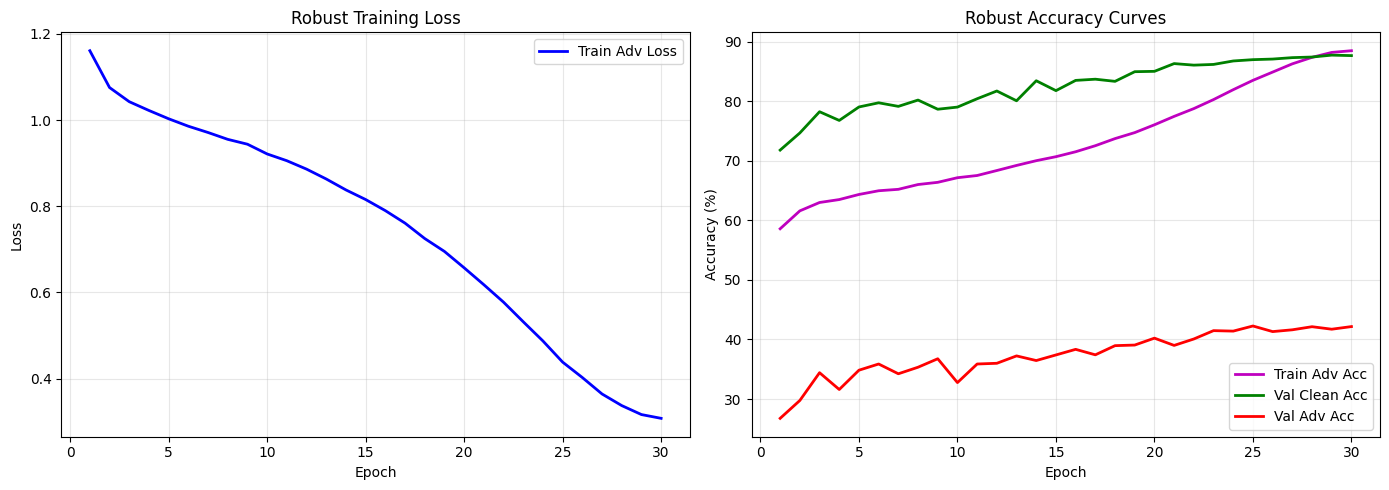

In [10]:
df_history = pd.DataFrame(history)
df_history.to_csv(CURVES_PATH, index=False)
print(f"Robust training curves saved to: {CURVES_PATH}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(df_history['epoch'], df_history['train_loss'], 'b-', linewidth=2, label='Train Adv Loss')
ax[0].set_title('Robust Training Loss')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
ax[0].legend(); ax[0].grid(True, alpha=0.3)

ax[1].plot(df_history['epoch'], df_history['train_adv_acc'], 'm-', linewidth=2, label='Train Adv Acc')
ax[1].plot(df_history['epoch'], df_history['val_clean_acc'], 'g-', linewidth=2, label='Val Clean Acc')
ax[1].plot(df_history['epoch'], df_history['val_adv_acc'], 'r-', linewidth=2, label='Val Adv Acc')
ax[1].set_title('Robust Accuracy Curves')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy (%)')
ax[1].legend(); ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CURVES_DIR}/robust_train_plot.png', dpi=150)
plt.show()

---
## Cell 8 — Final Evaluation

Test the strictly isolated test set.

In [12]:
best_model = create_resnet18_cifar10().to(DEVICE)
best_model.load_state_dict(torch.load('/kaggle/working/robust_resnet18.pth', map_location=DEVICE, weights_only=True))
best_model.eval()

def evaluate_with_steps(model, loader, criterion, pgd_steps=None):
    """Evaluate model — pgd_steps=None means clean, otherwise PGD attack with given steps."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        if pgd_steps is not None:
            images = pgd_attack(model, images, labels, PGD_EPSILON, PGD_ALPHA, pgd_steps)
            model.eval()

        with torch.no_grad():
            outputs = model(images)
            loss    = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()

    return running_loss / total, 100.0 * correct / total

print('Evaluating on held-out test set...')
_, test_clean_acc  = evaluate_with_steps(best_model, test_loader, criterion, pgd_steps=None)
_, test_adv_acc_5  = evaluate_with_steps(best_model, test_loader, criterion, pgd_steps=5)
_, test_adv_acc_10 = evaluate_with_steps(best_model, test_loader, criterion, pgd_steps=10)

print('=' * 48)
print('  Robust Model — Final Evaluation')
print('=' * 48)
print(f'  Clean Test Accuracy      : {test_clean_acc:.2f}%')
print(f'  PGD-5  Test Accuracy     : {test_adv_acc_5:.2f}%   ← trained on this')
print(f'  PGD-10 Test Accuracy     : {test_adv_acc_10:.2f}%   ← stronger unseen attack')
print(f'  Expected clean           : 75–85%')
print(f'  Expected adv             : 45–55%')
print('=' * 48)

# ── Per-class breakdown for all 3 scenarios ──
class_correct_clean = [0] * 10
class_correct_adv5  = [0] * 10
class_correct_adv10 = [0] * 10
class_total         = [0] * 10

for images, labels in test_loader:
    images, labels = images.to(DEVICE), labels.to(DEVICE)

    adv5  = pgd_attack(best_model, images, labels, PGD_EPSILON, PGD_ALPHA, 5);  best_model.eval()
    adv10 = pgd_attack(best_model, images, labels, PGD_EPSILON, PGD_ALPHA, 10); best_model.eval()

    with torch.no_grad():
        preds_clean = best_model(images).max(1)[1]
        preds_adv5  = best_model(adv5).max(1)[1]
        preds_adv10 = best_model(adv10).max(1)[1]

    for i in range(labels.size(0)):
        label = labels[i].item()
        class_total[label] += 1
        if preds_clean[i] == label: class_correct_clean[label] += 1
        if preds_adv5[i]  == label: class_correct_adv5[label]  += 1
        if preds_adv10[i] == label: class_correct_adv10[label] += 1

print(f'\nPer-class accuracy (test set):')
print(f'{"Class":<12} | {"Clean":>7} | {"PGD-5":>7} | {"PGD-10":>8}')
print('-' * 44)
for i in range(10):
    acc_c  = 100. * class_correct_clean[i] / class_total[i]
    acc_5  = 100. * class_correct_adv5[i]  / class_total[i]
    acc_10 = 100. * class_correct_adv10[i] / class_total[i]
    print(f'{CIFAR10_CLASSES[i]:<12} | {acc_c:>6.2f}% | {acc_5:>6.2f}% | {acc_10:>7.2f}%')

Evaluating on held-out test set...
  Robust Model — Final Evaluation
  Clean Test Accuracy      : 87.36%
  PGD-5  Test Accuracy     : 52.68%   ← trained on this
  PGD-10 Test Accuracy     : 43.02%   ← stronger unseen attack
  Expected clean           : 75–85%
  Expected adv             : 45–55%

Per-class accuracy (test set):
Class        |   Clean |   PGD-5 |   PGD-10
--------------------------------------------
airplane     |  90.00% |  61.60% |   51.60%
automobile   |  93.80% |  72.20% |   65.80%
bird         |  84.00% |  40.40% |   29.60%
cat          |  72.40% |  25.20% |   18.20%
deer         |  82.80% |  32.40% |   20.40%
dog          |  78.60% |  41.80% |   35.00%
frog         |  89.80% |  55.80% |   42.20%
horse        |  90.60% |  64.20% |   55.80%
ship         |  95.80% |  66.40% |   55.40%
truck        |  95.80% |  66.00% |   56.00%
